In [1]:
# Code for checking the catagorical columns
import pandas as pd

df = pd.read_csv("../data/raw/updated_pollution_dataset.csv")

df.info()

categorical_columns = df.select_dtypes(include=["object"]).columns
print(categorical_columns)


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 418.6 KB
Index(['Air Quality'], dtype='str')


C:\Users\USERAS\AppData\Local\Temp\ipykernel_18528\1192490557.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [2]:
import os
print(os.getcwd())

c:\Users\USERAS\air-quality-ml-project\notebooks


['Good' 'Hazardous' 'Moderate' 'Poor']


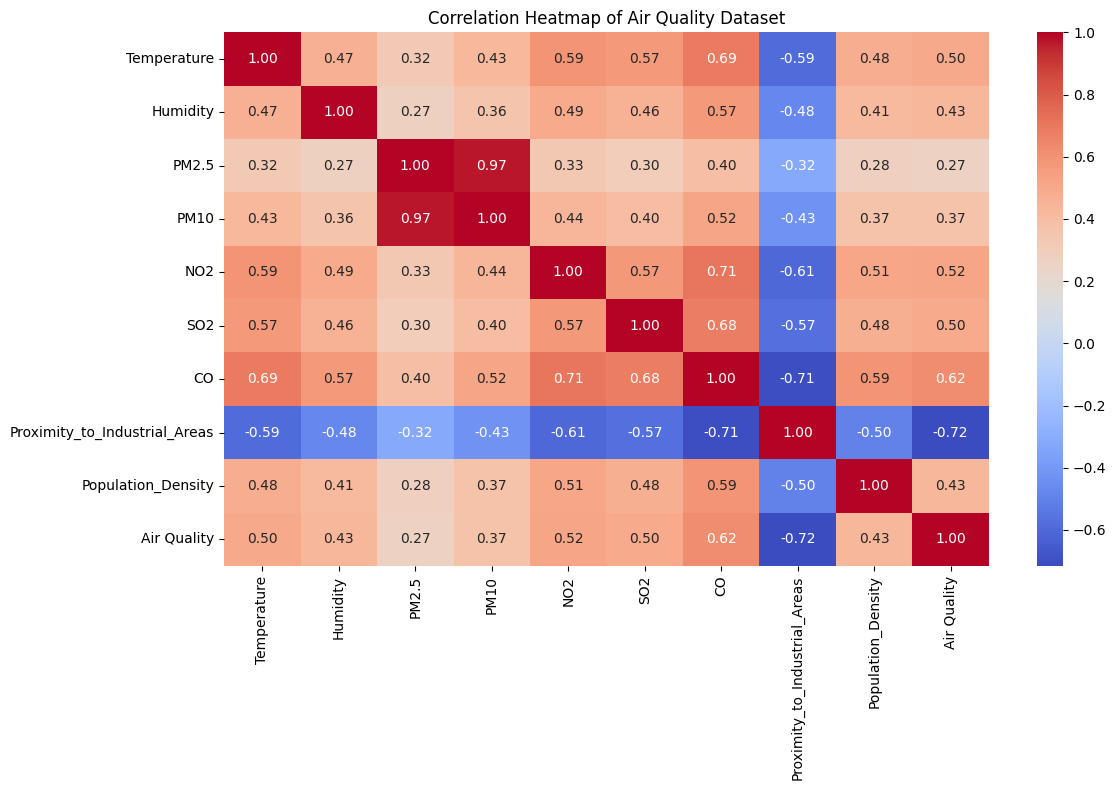

In [3]:
#Generating heatmaps 
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

df_encoded = df.copy()

label_encoder = LabelEncoder()
df_encoded["Air Quality"] = label_encoder.fit_transform(df_encoded["Air Quality"])

print(label_encoder.classes_)

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Air Quality Dataset")
plt.tight_layout()
plt.savefig("../outputs/plots/correlation_heatmap.png", dpi=300)
plt.show()

Class counts:
Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64
The dataset is imbalanced because all classes do not have equal number of instances.


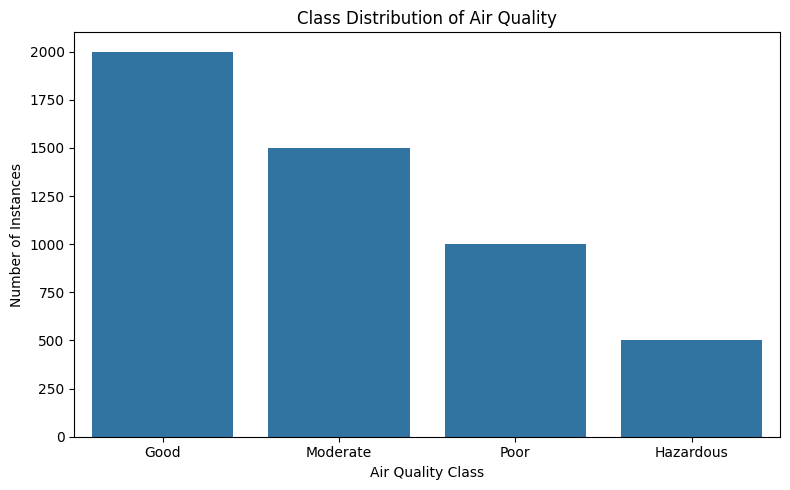

In [4]:
#Dataset Imbalanced or not 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/updated_pollution_dataset.csv")

# Count how many instances are in each class
class_counts = df["Air Quality"].value_counts()

print("Class counts:")
print(class_counts)

# Check if all classes have equal number of instances
if class_counts.nunique() == 1:
    print("The dataset is balanced because all classes have equal number of instances.")
else:
    print("The dataset is imbalanced because all classes do not have equal number of instances.")

# Bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution of Air Quality")
plt.xlabel("Air Quality Class")
plt.ylabel("Number of Instances")
plt.tight_layout()
plt.savefig("../outputs/plots/class_distribution.png", dpi=300)
plt.show()

In [5]:
#Summarize
df

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good
...,...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good


In [6]:
#Feature Names and its Datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   str    
dtypes: float64(8), int64(1), str(1)
memory usage: 418.6 KB


In [7]:
#Descriptive Analysis
numerical_data = df.select_dtypes(include = 'number')
catagorical_data  = df.select_dtypes(include = 'object')
numerical_data.describe().T



C:\Users\USERAS\AppData\Local\Temp\ipykernel_18528\1886206664.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catagorical_data  = df.select_dtypes(include = 'object')


,count,mean,std,min,25%,50%,75%,max
Temperature,5000.0,30.029020,6.720661,13.40,25.10,29.00,34.000,58.60
Humidity,5000.0,70.056120,15.863577,36.00,58.30,69.80,80.300,128.10
PM2.5,5000.0,20.142140,24.554546,0.00,4.60,12.00,26.100,295.00
PM10,5000.0,30.218360,27.349199,-0.20,12.30,21.70,38.100,315.80
NO2,5000.0,26.412100,8.895356,7.40,20.10,25.30,31.900,64.90
SO2,5000.0,10.014820,6.750303,-6.20,5.10,8.00,13.725,44.90
CO,5000.0,1.500354,0.546027,0.65,1.03,1.41,1.840,3.72
Proximity_to_Industrial_Areas,5000.0,8.425400,3.610944,2.50,5.40,7.90,11.100,25.80
Population_Density,5000.0,497.423800,152.754084,188.00,381.00,494.00,600.000,957.00


In [8]:
numerical_data.var()

Temperature                         45.167289
Humidity                           251.653065
PM2.5                              602.925723
PM10                               747.978707
NO2                                 79.127365
SO2                                 45.566596
CO                                   0.298145
Proximity_to_Industrial_Areas       13.038915
Population_Density               23333.810156
dtype: float64

In [9]:
catagorical_data.describe().T

,count,unique,top,freq
Air Quality,5000,4,Good,2000


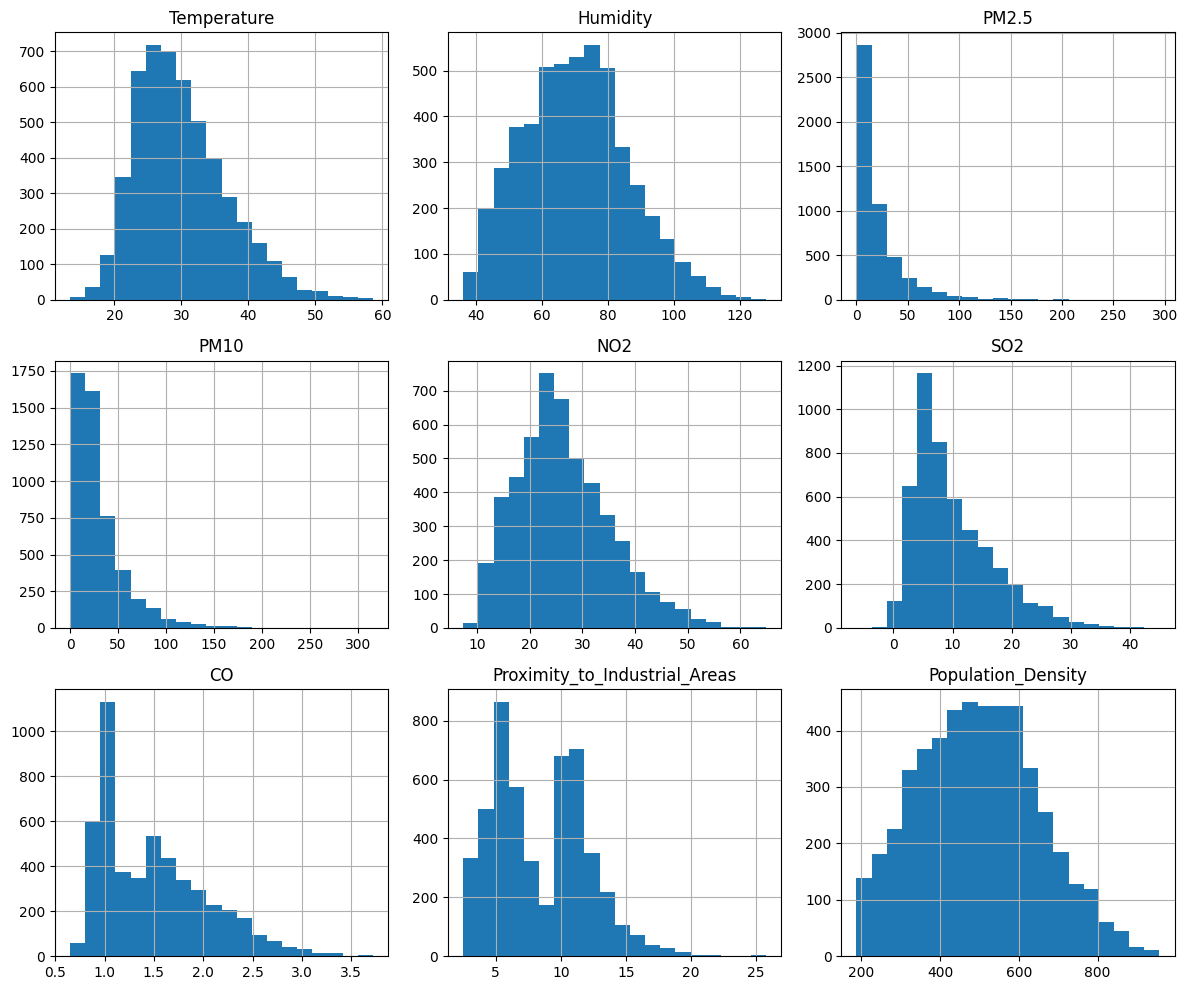

In [10]:
# Histograms of numerical features
import matplotlib.pyplot as plt

numerical_data.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

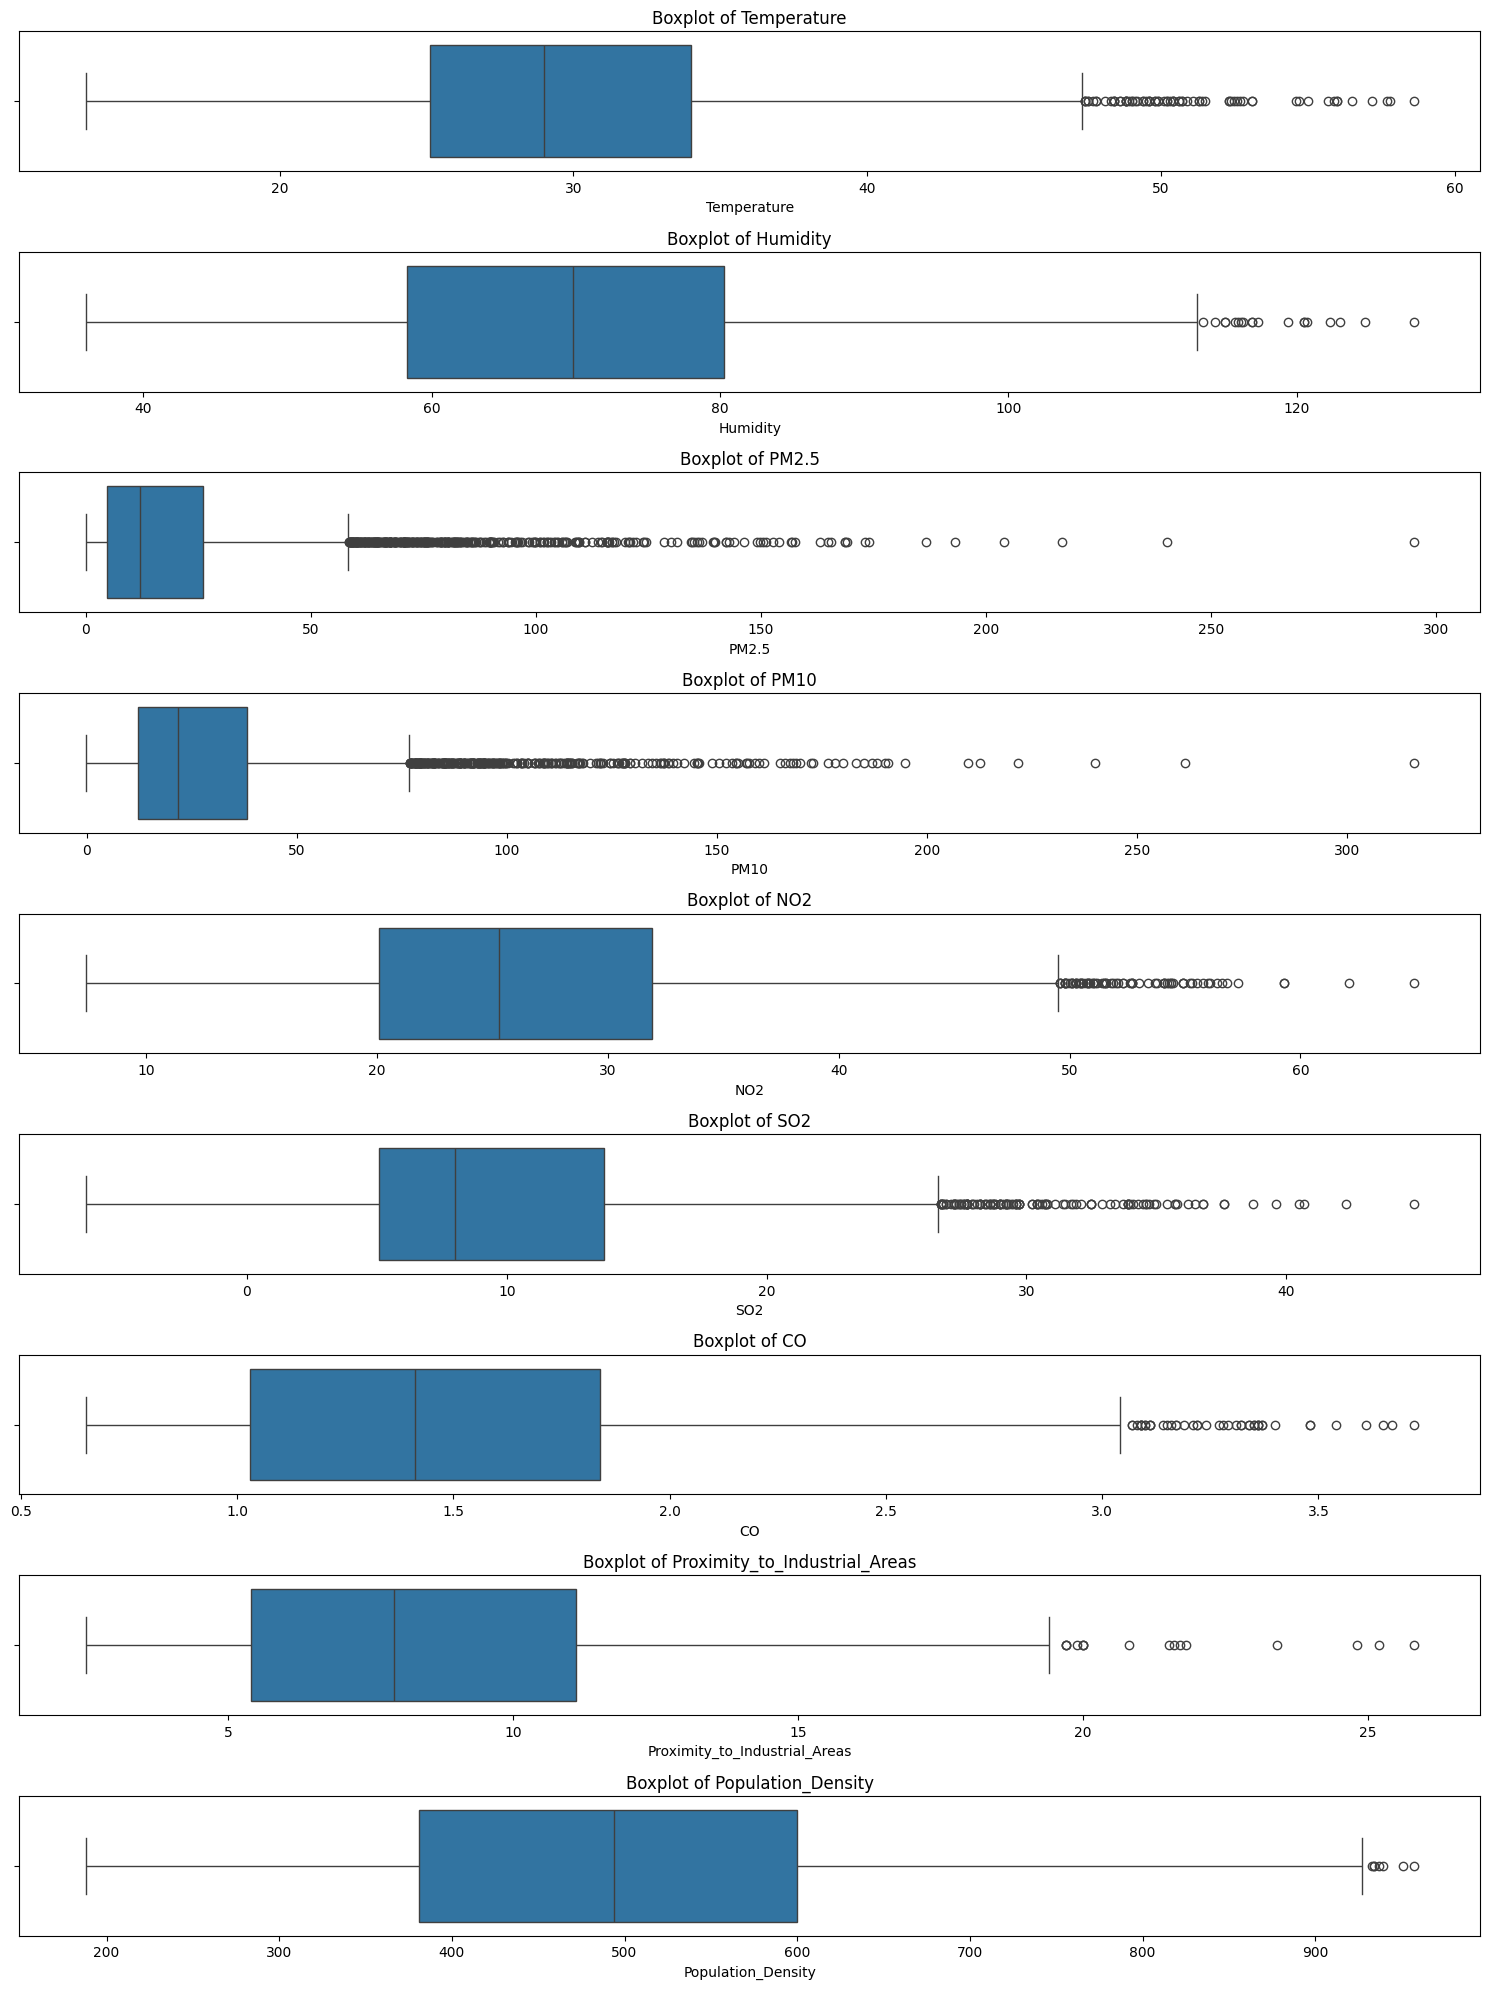

In [11]:
#11. Boxplots for outliers
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15, 20))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()

plt.show()

In [12]:
#Skewness
numerical_data = df.select_dtypes(include=["int64", "float64"])
print(numerical_data.skew())

Temperature                      0.752187
Humidity                         0.280528
PM2.5                            2.890910
PM10                             2.534815
NO2                              0.638783
SO2                              1.166772
CO                               0.879068
Proximity_to_Industrial_Areas    0.469752
Population_Density               0.204231
dtype: float64


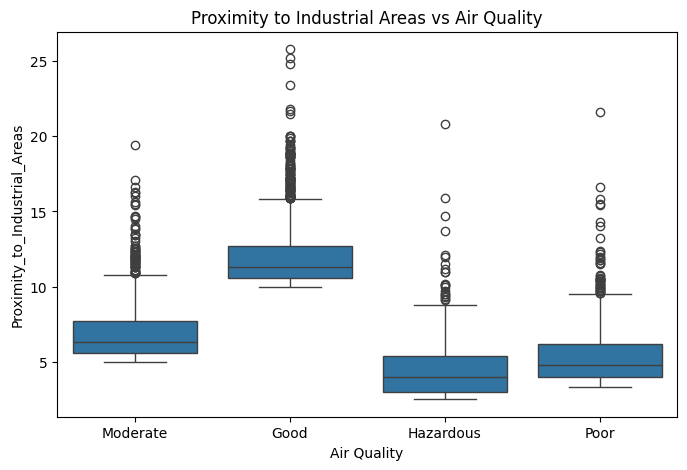

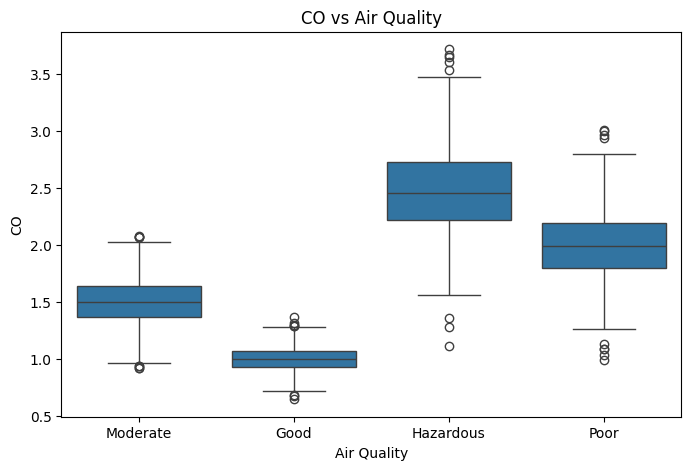

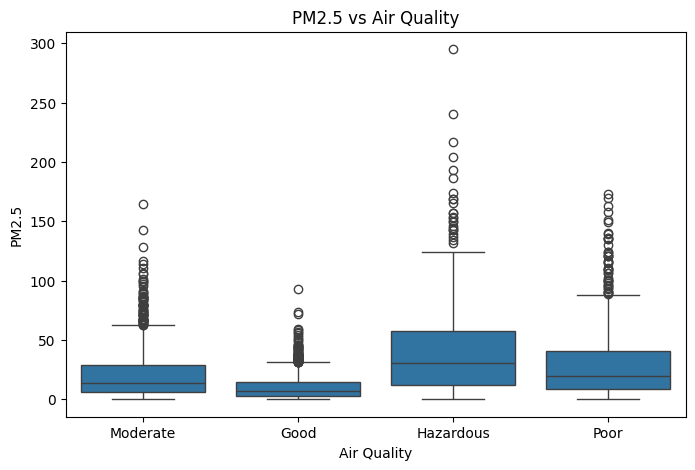

In [13]:
#3 plots 
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Air Quality", y="Proximity_to_Industrial_Areas")
plt.title("Proximity to Industrial Areas vs Air Quality")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Air Quality", y="CO")
plt.title("CO vs Air Quality")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Air Quality", y="PM2.5")
plt.title("PM2.5 vs Air Quality")
plt.show()

In [14]:
numerical_data.isnull().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
dtype: int64